# Karar Laboratuvarı 03 — Tahmin Ufku, Toplulaştırma veya Sınıf Sayısını Değiştirmek

**Ortak yazarlar:** Pusula (karar mantığı ve anlatı) · Rota (çalıştırılabilir analiz, montaj ve QA)  
**Durum:** Hedef sözleşmesi alternatifleri; yeni etiket/model performansı üretilmez  
**Kritik sınır:** Bu seçenek target sütununu koruyabilir, fakat kullanıcının üç sınıf veya aylık ufuk kararını değiştirebilir. Uygulama için yeni bağlayıcı K kararı gerekir.  
**Test:** Kilitli kalır

Bu notebook “daha uzun ufuk daha kolaydır” veya “iki sınıf daha başarılıdır” demez. Yalnız mevcut kanıtın hangi eksenleri sınadığını, hangilerini sınamadığını ve değişikliğin örneklem maliyetini gösterir.

## Okuma hedefleri

1. Stable bandı değişikliği ile sınıf sayısı değişikliğini ayırmak.
2. Model 11’in aylık lag teşhisinden hangi çıkarımların yapılabileceğini sınırlamak.
3. Daha uzun toplulaştırmanın efektif örneklem/origin sayısına maliyetini görmek.
4. Hedef sözleşmesi değişikliğinin neden yeni ön-kayıt ve kullanıcı onayı gerektirdiğini açıklamak.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def repo_kokunu_bul():
    baslangic = Path.cwd().resolve()
    for aday in [baslangic, *baslangic.parents]:
        if (aday / "README.md").exists() and (aday / "data").exists():
            return aday
    raise FileNotFoundError("Repo kökü bulunamadı. Notebook'u repo içinde çalıştırın.")

ROOT = repo_kokunu_bul()
MODEL_DIR = ROOT / "data" / "processed" / "model"

def json_oku(dosya_adi, fallback):
    yol = MODEL_DIR / dosya_adi
    if yol.exists():
        return json.loads(yol.read_text(encoding="utf-8")), f"canlı dosya: {yol.relative_to(ROOT)}"
    return fallback, f"raporda sabitlenmiş fallback: {dosya_adi}"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)
print("Repo:", ROOT)

Repo: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler - Kopya - Kopya


In [2]:
M11_FALLBACK = {
 "analiz_penceresi":["2019-01","2025-04"],
 "bolum2_gecis_lag":{
   "gecis_bagimsizlik_permutasyon":{"cramer_v":0.0980533112,"permutasyon_p":0.8450154985},
   "lag_cramer":{
     "1":{"cramer_v":0.0980533112,"holm":{"holm_duzeltilmis_p":1.0,"h0_reddedildi":False}},
     "2":{"cramer_v":0.2164726561,"holm":{"holm_duzeltilmis_p":0.5755424458,"h0_reddedildi":False}},
     "3":{"cramer_v":0.1168428124,"holm":{"holm_duzeltilmis_p":1.0,"h0_reddedildi":False}},
     "12":{"cramer_v":0.1159694024,"holm":{"holm_duzeltilmis_p":1.0,"h0_reddedildi":False}}
   }},
 "bolum3_stable_band_duyarliligi":{
   "2.5":{"sinif_paylari":{"down":.4342105263,"stable":.0657894737,"up":.5},"persistence_m2":{"mcc":.0099080592},"ana_esige_delta_mcc":-.0066000404,"maddi_farkli":False},
   "3.5":{"sinif_paylari":{"down":.3815789474,"stable":.1447368421,"up":.4736842105},"persistence_m2":{"mcc":-.0784834909},"ana_esige_delta_mcc":-.0949915905,"maddi_farkli":False},
   "5.0":{"sinif_paylari":{"down":.3684210526,"stable":.1842105263,"up":.4473684211},"persistence_m2":{"mcc":.0165080996},"ana_esige_delta_mcc":0.0,"maddi_farkli":False},
   "7.5":{"sinif_paylari":{"down":.3157894737,"stable":.3289473684,"up":.3552631579},"persistence_m2":{"mcc":-.0296970570},"ana_esige_delta_mcc":-.0462051565,"maddi_farkli":False},
   "10.0":{"sinif_paylari":{"down":.3026315789,"stable":.3815789474,"up":.3157894737},"persistence_m2":{"mcc":-.0996333263},"ana_esige_delta_mcc":-.1161414258,"maddi_farkli":False}
 },
 "test":"2025-07..2026-06 ACILMADI_KILITLI"
}
m11, kaynak11 = json_oku("model_11_hedef_teshis_ozet.json", M11_FALLBACK)
print(kaynak11)

canlı dosya: data\processed\model\model_11_hedef_teshis_ozet.json


## Önce elenmiş ekseni ayır: stable bandı

Model 11, ±%2.5, ±%3.5, ±%5, ±%7.5 ve ±%10 bandını aynı protokol içinde taradı. Ön-kayıtlı “maddi farklı” kuralı: persistence MCC ana bandı en az 0.10 aşacak ve farkın güven aralığı alt sınırı pozitif olacak. Hiçbir bant bu kapıyı geçmedi.

Bu bulgu **üç sınıfın gereksiz olduğunu kanıtlamaz**. Yalnız üç sınıf korunurken stable genişliğini değiştirme ekseninin mevcut örneklemde çözüm üretmediğini gösterir.

In [3]:
band = m11["bolum3_stable_band_duyarliligi"]
band_df = pd.DataFrame([
    [float(esik), v["sinif_paylari"]["down"], v["sinif_paylari"]["stable"],
     v["sinif_paylari"]["up"], v["persistence_m2"]["mcc"],
     v["ana_esige_delta_mcc"], v["maddi_farkli"]]
    for esik, v in band.items()
], columns=["stable_esik_pct","down_payı","stable_payı","up_payı",
            "persistence_mcc","ana_esige_delta_mcc","maddi_farkli"]).sort_values("stable_esik_pct")
band_df

,stable_esik_pct,down_payı,stable_payı,up_payı,persistence_mcc,ana_esige_delta_mcc,maddi_farkli
0,2.5,0.434211,0.065789,0.500000,0.009908,-0.006600,False
1,3.5,0.381579,0.144737,0.473684,-0.078483,-0.094992,False
2,5.0,0.368421,0.184211,0.447368,0.016508,0.000000,False
3,7.5,0.315789,0.328947,0.355263,-0.029697,-0.046205,False
4,10.0,0.302632,0.381579,0.315789,-0.099633,-0.116141,False


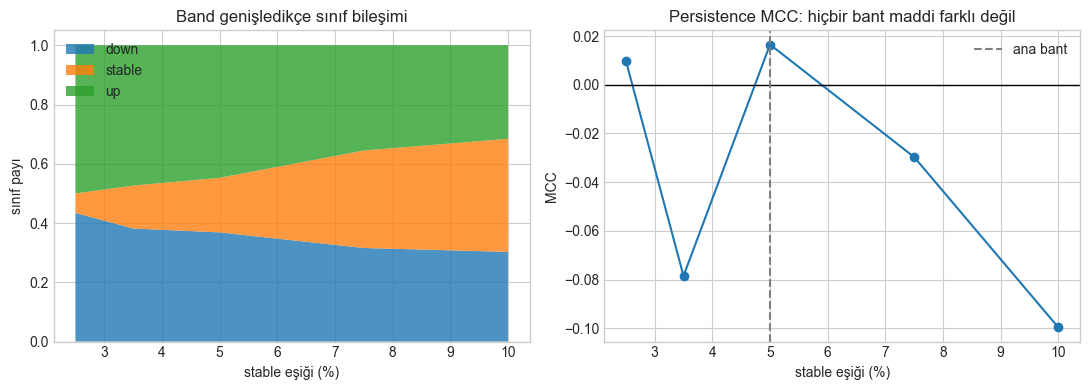

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].stackplot(
    band_df["stable_esik_pct"], band_df["down_payı"], band_df["stable_payı"], band_df["up_payı"],
    labels=["down","stable","up"], alpha=.8
)
axes[0].set(title="Band genişledikçe sınıf bileşimi", xlabel="stable eşiği (%)", ylabel="sınıf payı")
axes[0].legend(loc="upper left")
axes[1].plot(band_df["stable_esik_pct"], band_df["persistence_mcc"], marker="o")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axvline(5, color="grey", linestyle="--", label="ana bant")
axes[1].set(title="Persistence MCC: hiçbir bant maddi farklı değil", xlabel="stable eşiği (%)", ylabel="MCC")
axes[1].legend()
plt.tight_layout()
plt.show()

## Aylık hafıza teşhisi ne söyler, ne söylemez?

Aylık sınıf geçiş matrisi bağımsızlıktan ayrışmadı (permütasyon p≈0.845). Lag 1, 2, 3 ve 12 için Cramér’s V testlerinin hiçbiri Holm düzeltmesinden sonra anlamlı değildi.

Bu, **incelenen aylık etiket serisinde güvenilir gecikme yapısı gösterilemediği** anlamına gelir. Üç aylık toplamın da hafızasız olacağını kanıtlamaz; çünkü üç aylık hedef hiç kurulup sınanmadı. Tersine, üç aylık hedefin daha kolay olacağını da göstermez.

In [5]:
lag = m11["bolum2_gecis_lag"]["lag_cramer"]
lag_df = pd.DataFrame([
    [int(k), v["cramer_v"], v["holm"]["holm_duzeltilmis_p"], v["holm"]["h0_reddedildi"]]
    for k, v in lag.items()
], columns=["lag_ay","cramer_v","holm_duzeltilmis_p","bagimsizlik_reddedildi"]).sort_values("lag_ay")
lag_df

,lag_ay,cramer_v,holm_duzeltilmis_p,bagimsizlik_reddedildi
0,1,0.098053,1.000000,False
1,2,0.216473,0.575542,False
2,3,0.116843,1.000000,False
3,12,0.115969,1.000000,False


## Üç ayrı değişiklik türü

| Alt seçenek | Değişen sözleşme | Ana istatistiksel maliyet | Bu notebookta ölçülüyor mu? |
|---|---|---|---|
| Ufku büyütmek | gelecek ay → gelecek 3 ay/çeyrek yönü | daha az bağımsız değerlendirme birimi; CI genişleyebilir | Hayır |
| Toplulaştırmayı değiştirmek | aylık toplam → hareketli 4/8/12 hafta vb. | örtüşen hedefler bağımlılık yaratır; embargo yeniden türetilir | Hayır |
| Sınıfı 3→2 yapmak | stable sınıfını kaldırmak/birleştirmek | karar anlamı değişir; stable gözlemleri için kural gerekir | Hayır |

Üç değişikliği tek deneyde birleştirmek yasaktır: hangi değişikliğin sonucu etkilediği ayrıştırılamaz.

In [6]:
baslangic = pd.Period(m11.get("analiz_penceresi", ["2019-01"])[0], freq="M")
bitis = pd.Period(m11.get("analiz_penceresi", ["","2025-04"])[1], freq="M")
ay_sayisi = bitis.ordinal - baslangic.ordinal + 1

fizibilite = pd.DataFrame([
    ["aylık / 1 ay", 1, ay_sayisi, "Mevcut sözleşme"],
    ["örtüşmesiz / 3 ay", 3, ay_sayisi // 3, "Üst sınır; eğitim ve embargo düşülmedi"],
    ["örtüşmesiz / 6 ay", 6, ay_sayisi // 6, "Üst sınır; rolling-origin için çok düşük"],
    ["hareketli / 3 ay", 3, ay_sayisi - 2, "Gözlem çok görünür ama hedefler örtüşür; bağımsız origin değildir"],
], columns=["toplulaştırma","pencere_ay","ham_birim_üst_sınırı","uyarı"])
print(f"Analiz penceresi: {baslangic}..{bitis} ({ay_sayisi} ay)")
fizibilite

Analiz penceresi: 2019-01..2025-04 (76 ay)


,toplulaştırma,pencere_ay,ham_birim_üst_sınırı,uyarı
0,aylık / 1 ay,1,76,Mevcut sözleşme
1,örtüşmesiz / 3 ay,3,25,Üst sınır; eğitim ve embargo düşülmedi
2,örtüşmesiz / 6 ay,6,12,Üst sınır; rolling-origin için çok düşük
3,hareketli / 3 ay,3,74,Gözlem çok görünür ama hedefler örtüşür; bağımsız origin değildir


### Fizibilite tablosu nasıl okunur?

2019-01..2025-04 arası 76 aylık pencere, örtüşmesiz üç aylık hedefte en fazla 25 ham birim üretir. Bu sayı eğitim başlangıcı, iki aylık bilgi gecikmesi, embargo ve değerlendirme ayrımı düşülmeden önceki **iyimser üst sınırdır**. Dolayısıyla Model 10’daki 50 origin düzeyine ulaşılamaz.

Hareketli üç aylık hedef 74 satır üretebilir; ancak yan yana hedefler iki ayı paylaşır. Satır sayısı origin bağımsızlığı değildir. Bootstrap blok yapısı ve embargo hedef örtüşmesine göre yeniden tasarlanmalıdır.

## 3→2 sınıf dönüşümünde çözülmesi gereken karar

Mevcut ±%5 tanımında stable payı yaklaşık %18.4’tür. Stable gözlemlerini down/up’a “en yakın sınıf” diye dağıtmak tarafsız değildir; işaret sıfıra yakın olduğundan küçük ölçüm/revizyon farklarını yön sınıfına zorlar. Stable satırlarını düşürmek ise örneklemi küçültür ve tahmin görevinin popülasyonunu değiştirir.

Bu nedenle iki sınıflı hedef için önce şu semantik seçilmelidir:

- stable ayları dışlamak,
- stable ayları maliyet-duyarlı belirsiz/abstain kararı olarak tutmak,
- ya da yönü ikili yapıp stable’a ayrı güven/işlem katmanı tanımlamak.

Bu notebook hiçbir dönüşümde MCC hesaplamaz. Ön-kayıtsız keşifsel skor, yeni sözleşmeyi olduğundan daha güçlü gösterebilir.

In [7]:
hedef_sozlesmesi_sablonu = pd.DataFrame([
    ["ufuk", "1 ay", "", "Operasyonel karar hangi dönemi kapsayacak?"],
    ["toplulaştırma", "aylık toplam", "", "Örtüşme ve takvim sınırı nasıl ele alınacak?"],
    ["sınıf sayısı", "3", "", "Stable'ın iş anlamı korunacak mı?"],
    ["stable kuralı", "±%5", "", "İki sınıfta stable gözlemlerine ne olacak?"],
    ["bilgi kesimi", "M−2", "", "Yeni ufukta yayın gecikmesi nasıl maskelenecek?"],
    ["embargo", "2 ay", "", "Hedef penceresiyle birlikte kaç ay olmalı?"],
    ["birincil metrik", "MCC + macro-F1", "", "Sınıf değişince metrik sözleşmesi değişecek mi?"],
], columns=["alan","mevcut_deger","önerilen_deger","karar_sorusu"])
hedef_sozlesmesi_sablonu

,alan,mevcut_deger,önerilen_deger,karar_sorusu
0,ufuk,1 ay,,Operasyonel karar hangi dönemi kapsayacak?
1,toplulaştırma,aylık toplam,,Örtüşme ve takvim sınırı nasıl ele alınacak?
2,sınıf sayısı,3,,Stable'ın iş anlamı korunacak mı?
3,stable kuralı,±%5,,İki sınıfta stable gözlemlerine ne olacak?
4,bilgi kesimi,M−2,,Yeni ufukta yayın gecikmesi nasıl maskelenecek?
5,embargo,2 ay,,Hedef penceresiyle birlikte kaç ay olmalı?
6,birincil metrik,MCC + macro-F1,,Sınıf değişince metrik sözleşmesi değişecek mi?


## Yanlış yorumlama kontrol listesi

- Daha uzun ufuk otomatik olarak daha kolay değildir; gürültü azalırken bağımsız örnek sayısı da azalır.
- Daha az sınıf otomatik olarak daha yüksek gerçek beceri değildir; görev ve hata maliyeti değişir.
- 74 hareketli üç aylık satır, 74 bağımsız değerlendirme origin’i değildir.
- Stable band taramasının başarısızlığı, iki sınıfın başarılı olacağına dair pozitif kanıt değildir.
- Bu seçenek target sütununu korusa bile kullanıcı tarafından sabitlenen üç sınıf/aylık nowcast sözleşmesini değiştirebilir; bağlayıcı karar olmadan uygulanamaz.

## Karar kapısı

Seçenek 3 yalnız şu koşullarla ön-kayıda taşınabilir:

1. Proje sahibi değişecek sözleşme alanını açıkça onaylar.
2. Aynı anda tek eksen değişir: ufuk **veya** toplulaştırma **veya** sınıf semantiği.
3. Ham birim üst sınırı, eğitim/embargo sonrası planlanan minimum origin sayısını karşılar.
4. Yeni bilgi kesimi, embargo, metrik ve terfi eşiği sonuç görülmeden yazılır.
5. Kilitli test yeni hedefe uyarlanmış olsa bile geliştirme sırasında açılmaz.

Bu koşullar yoksa seçenek bilimsel olarak “ölçülmemiş hipotez” konumunda kalır.

## Ortak karar puanlama şeması

Üç seçenek aynı dört eksende 0–3 puanlanır. Bu tablo otomatik kazanan üretmez; puan ile gerekçenin birlikte kaydedilmesini zorunlu kılar.

| Eksen | 0 puan | 3 puan |
|---|---|---|
| Kanıt gücü | Spekülasyon | Model 09→10→11 zincirinin doğrudan sonucu |
| Maliyet / tersinirlik | K değişikliği, yeni ön-kayıt ve/veya yeni kaynak | Yalnız dokümantasyon; karar geri alınabilir |
| Belirsizlik azaltımı | Yeni ve büyük bir açık soru seti doğurur | Mevcut açık soruyu kapatır |
| Kapsam sadakati | Sabit hedef/sınıf/ufuk kararını değiştirir | Sabitlerin hiçbirine dokunmaz |

Puanlar tek başına karar değildir. Her puanın yanına kanıt referansı yazılmadan toplam alınmamalıdır.

In [8]:
puanlama_sablonu = pd.DataFrame(
    [
        ["1 — hedefi kapat", pd.NA, pd.NA, pd.NA, pd.NA, ""],
        ["2 — bilgi kümesini genişlet", pd.NA, pd.NA, pd.NA, pd.NA, ""],
        ["3 — ufuk/toplulaştırma/sınıf değiştir", pd.NA, pd.NA, pd.NA, pd.NA, ""],
    ],
    columns=["seçenek", "kanıt_gücü_0_3", "maliyet_tersinirlik_0_3",
             "belirsizlik_azaltımı_0_3", "kapsam_sadakati_0_3", "kanıt_gerekçesi"],
)
puanlama_sablonu

,seçenek,kanıt_gücü_0_3,maliyet_tersinirlik_0_3,belirsizlik_azaltımı_0_3,kapsam_sadakati_0_3,kanıt_gerekçesi
0,1 — hedefi kapat,<NA>,<NA>,<NA>,<NA>,
1,2 — bilgi kümesini genişlet,<NA>,<NA>,<NA>,<NA>,
2,3 — ufuk/toplulaştırma/sınıf değiştir,<NA>,<NA>,<NA>,<NA>,


## Sonuç

Model 11 stable bandını ve aylık gecikmeleri sınadı; alternatif ufukları veya iki sınıflı hedefi sınamadı. Bu nedenle seçenek 3 ne doğrulanmış ne de çürütülmüştür. Notebook, değişiklikten önce gereken sözleşme ve fizibilite disiplinini görünür kılar.